In [5]:
!pip install xgboost joblib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

In [6]:
# Configuration for your building data
DATA_FOLDER = './'

# CSV file paths
ENERGY_FILE = f'{DATA_FOLDER}/Cooling_Heating_Electricity_w_Shading.csv'
TEMPERATURE_FILE = f'{DATA_FOLDER}/Temperatures_w_Shading.csv'
DNI_FILE = f'{DATA_FOLDER}/DNI_w_Shading.csv'
SHADING_FILE = f'{DATA_FOLDER}/Shading_actions.csv'

# Energy conversion factors (adjust these for your building if needed)
PE_GAS = 1.00       # Primary energy factor for gas
PE_ELEC = 2.17      # Primary energy factor for electricity
COP_H = 0.98        # Coefficient of Performance for heating
EER_C = 5.4         # Energy Efficiency Ratio for cooling

In [7]:
class PredictionModel:
    def __init__(self):
        self.X_train, self.y_train = [], []
        self.X_test, self.y_test = [], []
        self.model = None
        self.dataset = None

        # Configuration
        self.PE_GAS = PE_GAS
        self.PE_ELEC = PE_ELEC
        self.COP_H = COP_H
        self.EER_C = EER_C

    def load_from_csv(self, energy_file, temperature_file, dni_file, shading_file):
        """
        Load and merge data from CSV files exported from InfluxDB.
        Returns a cleaned DataFrame ready for feature engineering.
        """
        print("Loading CSV files...")

        # Load individual CSV files
        df_energy = pd.read_csv(energy_file)
        df_temp = pd.read_csv(temperature_file)
        df_dni = pd.read_csv(dni_file)
        df_shading = pd.read_csv(shading_file)

        # Rename 'Time' column to 'time' for consistency
        for df in [df_energy, df_temp, df_dni, df_shading]:
            df.rename(columns={'Time': 'time'}, inplace=True)

        # Convert time columns to datetime
        for df in [df_energy, df_temp, df_dni, df_shading]:
            df['time'] = pd.to_datetime(df['time'])

        # Start with energy data as base
        dataset = df_energy.copy()

        # Merge temperature data
        dataset = dataset.merge(df_temp, on='time', how='outer')

        # Merge DNI data
        dataset = dataset.merge(df_dni, on='time', how='outer')

        # Merge shading data
        dataset = dataset.merge(df_shading, on='time', how='outer')

        # Sort by time
        dataset = dataset.sort_values('time').reset_index(drop=True)

        # --- Drop rows where energy columns are NaN BEFORE forward-filling ---
        # Energy meters must have a real reading; forward-filling them would
        # create fake repeated values at the head/tail of the dataset (where
        # the simulation has not yet produced data or has already stopped).
        energy_cols_raw = [c for c in dataset.columns
                           if any(k in c for k in ('DistrictCooling', 'DistrictHeating', 'Electricity'))]
        dataset = dataset.dropna(subset=energy_cols_raw)

        # Forward fill auxiliary signals (temperature, DNI, shading) only
        dataset = dataset.ffill()

        # Drop any remaining NaN values (beginning of auxiliary columns)
        dataset = dataset.dropna()

        print(f"Loaded {len(dataset)} records")
        print(f"Date range: {dataset['time'].min()} to {dataset['time'].max()}")
        print(f"Columns: {list(dataset.columns)}")

        # Rename columns to match the expected names
        column_mapping = {}

        # Map energy columns
        for col in dataset.columns:
            if 'DistrictCooling' in col:
                column_mapping[col] = 'DistrictCooling'
            elif 'DistrictHeating' in col:
                column_mapping[col] = 'DistrictHeating'
            elif 'Electricity' in col and 'DistrictCooling' not in col and 'DistrictHeating' not in col:
                column_mapping[col] = 'Electricity'
            # Map temperature columns
            elif 'Tin_Flat2_Zona1' in col or 'Zona1' in col and 'Tin' in col:
                column_mapping[col] = 'Tair_z1'
            elif 'Tin_Flat2_Zona2' in col or 'Zona2' in col and 'Tin' in col:
                column_mapping[col] = 'Tair_z2'
            elif 'Tin_Flat2_Zona3' in col or 'Zona3' in col and 'Tin' in col:
                column_mapping[col] = 'Tair_z3'
            elif 'Tin_Flat2_Zona4' in col or 'Zona4' in col and 'Tin' in col:
                column_mapping[col] = 'Tair_z4'
            elif 'Tout' in col:
                column_mapping[col] = 'T_ext'
            # Map DNI
            elif 'DNI' in col:
                column_mapping[col] = 'DNI'
            # Map shading columns (Flat2 only, exclude stairs)
            elif 'A_Shade_Flat2_Z1_W2' in col:
                column_mapping[col] = 'Zona1_wall2_shade'
            elif 'A_Shade_Flat2_Z1_W8' in col:
                column_mapping[col] = 'Zona1_wall8_shade'
            elif 'A_Shade_Flat2_Z1_W9' in col:
                column_mapping[col] = 'Zona1_wall9_shade'
            elif 'A_Shade_Flat2_Z2_W2' in col:
                column_mapping[col] = 'Zona2_wall2_shade'
            elif 'A_Shade_Flat2_Z2_W3' in col:
                column_mapping[col] = 'Zona2_wall3_shade'
            elif 'A_Shade_Flat2_Z4_W2' in col:
                column_mapping[col] = 'Zona4_wall2_shade'

        dataset.rename(columns=column_mapping, inplace=True)

        energy_fields = ['Electricity', 'DistrictHeating', 'DistrictCooling']

        # Convert energy data from Joules to KWh
        for field in energy_fields:
            if field in dataset.columns:
                dataset[field] = dataset[field] / 3600000

        print(f"\nEnergy values (KWh):")
        for field in energy_fields:
            if field in dataset.columns:
                print(f"  {field}: {dataset[field].iloc[10:15].values}")

        print(f"\nColumn mapping complete. Final columns: {list(dataset.columns)}")

        dataset.to_csv('dataset.csv', index=False)

        return dataset

    def split(self, dataset, train_ratio=0.8):
        """
        Prepare features and targets, then split into training and testing sets.
        The split is chronological (no shuffle) which is correct for time series:
        shuffling would cause data leakage through the lag features.
        """
        print(f"\nFeature engineering...")

        # Store original dataset
        self.dataset = dataset.copy()

        # Feature Engineering
        # 1. Mean Air Temperature across zones
        tair_cols = ['Tair_z1', 'Tair_z2', 'Tair_z3', 'Tair_z4']
        dataset['Tair_mean'] = dataset[tair_cols].mean(axis=1)

        # 2. Delta T Indoor-Outdoor
        dataset['DeltaT'] = dataset['Tair_mean'] - dataset['T_ext']

        # 3. Average Shade Position (only Flat2 zones)
        shade_cols = [
            'Zona1_wall2_shade',
            'Zona1_wall8_shade',
            'Zona1_wall9_shade',
            'Zona2_wall2_shade',
            'Zona2_wall3_shade',
            'Zona4_wall2_shade'
        ]
        # Normalize by maximum shade value (typically 7.0 for these systems)
        dataset['mean_shade'] = dataset[shade_cols].mean(axis=1) / 7.0

        # 4. Temporal Features - Cyclical encoding for understanding daily and seasonal patterns
        dataset['hour'] = dataset['time'].dt.hour
        dataset['hour_sin'] = np.sin(2 * np.pi * dataset['hour'] / 24)
        dataset['hour_cos'] = np.cos(2 * np.pi * dataset['hour'] / 24)

        dataset['dayofyear'] = dataset['time'].dt.dayofyear
        dataset['doy_sin'] = np.sin(2 * np.pi * dataset['dayofyear'] / 365)
        dataset['doy_cos'] = np.cos(2 * np.pi * dataset['dayofyear'] / 365)

        # 5. Lag Features (previous timestep values) - to capture temporal dependencies of actual value with previous value
        for w in [1, 2, 3]:
            dataset[f'Electricity_lag{w}'] = dataset['Electricity'].shift(w)
            dataset[f'Cooling_lag{w}']     = dataset['DistrictCooling'].shift(w)
            dataset[f'Heating_lag{w}']     = dataset['DistrictHeating'].shift(w)

        # Drop rows with NaN from lag features (first row)
        dataset = dataset.dropna()

        # Define feature columns of the dataset
        X_cols = [
            'T_ext',    # external temperature
            'DNI',   # direct normal irradiance
            'Tair_mean',    # indoor mean temperature
            'DeltaT',   # temperature difference between indoor and outdoor
            'mean_shade',   # average shade position in the building
            'hour_sin', # daytime pattern
            'hour_cos', # daytime pattern
            'doy_sin',  # day of the year pattern
            'doy_cos',  # day of the year pattern
            *[f'Electricity_lag{w}' for w in [1, 2, 3]],
            *[f'Heating_lag{w}' for w in [1, 2, 3]],
            *[f'Cooling_lag{w}' for w in [1, 2, 3]],
        ]
        X = dataset[X_cols] # compose the dataset with the features defined

        # Target: Energy consumption components
        y = dataset[['Electricity', 'DistrictHeating', 'DistrictCooling']]

        # Chronological split (no shuffle) — correct for time series to avoid
        # data leakage: future lag values must never appear in the training set.
        split_point = int(len(X) * train_ratio)
        self.X_train, self.y_train = X.iloc[:split_point], y.iloc[:split_point]
        self.X_test, self.y_test = X.iloc[split_point:], y.iloc[split_point:]

        print(f"Training set: {len(self.X_train)} samples")
        print(f"Testing set: {len(self.X_test)} samples")
        print(f"Features: {X_cols}")

        # store in a csv the train and test set
        self.X_train.to_csv('X_train.csv', index=False)
        self.y_train.to_csv('y_train.csv', index=False)
        self.X_test.to_csv('X_test.csv', index=False)
        self.y_test.to_csv('y_test.csv', index=False)

    def compute_total_primary_energy(self, df):
        """
        Compute Total Primary Energy from individual energy components.
        """
        df['Total_Primary_Energy'] = (
            (df['DistrictHeating'] / self.COP_H * self.PE_GAS) +
            (df['DistrictCooling'] / self.EER_C * self.PE_ELEC) +
            (df['Electricity'] * self.PE_ELEC)
        )
        return df

    def train(self):
        """Train the XGBoost multi-output regression model."""
        print(f"\nTraining XGBoost model...")

        model = xgb.XGBRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            random_state=42
        )
        self.model = MultiOutputRegressor(model)
        self.model.fit(self.X_train, self.y_train)

        print("Model training complete!")

    def get_test_predictions(self):
        """Calculate predictions on the test set."""
        if self.model is None:
            raise ValueError("Model is not trained. Please run train() first.")
        if self.X_test.empty or self.y_test.empty:
            raise ValueError("Test data is not available. Please run split() first.")

        y_pred = self.model.predict(self.X_test)
        return y_pred

    def test_and_evaluate(self):
        """Evaluate the model performance on test set."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        print(f"\n=== Model Evaluation Results ===\n")

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)
        df_actual = self.compute_total_primary_energy(df_actual)

        all_targets = targets + ['Total_Primary_Energy']

        # Evaluate each target
        for target_name in all_targets:
            nmse = mean_squared_error(df_actual[target_name], df_pred[target_name]) / (df_actual[target_name].var() + 1e-8)
            mse = mean_squared_error(df_actual[target_name], df_pred[target_name])
            r2 = r2_score(df_actual[target_name], df_pred[target_name])
            print(f"{target_name:25s} -> NMSE: {nmse:.8e}, MSE: {mse:.8e}, R²: {r2:.4f}")

    def save_model(self, filepath):
        """Save the trained model to disk."""
        if self.model is None:
            print("Model is not trained. Cannot save.")
            return

        try:
            joblib.dump(self.model, filepath)
            print(f"Model saved to: {filepath}")
        except Exception as e:
            print(f"Failed to save model: {e}")

    def load_model(self, filepath):
        """Load a pre-trained model from disk."""
        try:
            self.model = joblib.load(filepath)
            print(f"Model loaded from: {filepath}")
        except FileNotFoundError:
            print(f"Model file not found: {filepath}")
        except Exception as e:
            print(f"Failed to load model: {e}")

    # === Visualization Methods ===

    def plot_feature_importance(self):
        """Plot feature importance for each output."""
        if self.model is None:
            print("Model not trained.")
            return

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        feature_names = self.X_train.columns.tolist()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for i, target_name in enumerate(targets):
            booster = self.model.estimators_[i].get_booster()
            booster.feature_names = feature_names

            xgb.plot_importance(booster, importance_type='gain', ax=axes[i],
                                show_values=False, title=f"{target_name}")

        plt.tight_layout()
        plt.show()

    def plot_scatter_error(self):
        """Plot predicted vs actual values with error coloring."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)
        df_actual = self.compute_total_primary_energy(df_actual)

        # Sample if dataset is too large
        if len(df_actual) > 10000:
            sample_idx = df_actual.sample(10000).index
            df_actual = df_actual.loc[sample_idx]
            df_pred = df_pred.loc[sample_idx]

        all_targets = targets + ['Total_Primary_Energy']

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()

        for i, col in enumerate(all_targets):
            actual = df_actual[col]
            pred = df_pred[col]
            errors = np.abs(pred - actual)

            sc = axes[i].scatter(actual, pred, c=errors, cmap="coolwarm", s=20, alpha=0.7)
            fig.colorbar(sc, ax=axes[i], label="Abs Error")

            # Identity line
            min_val = min(actual.min(), pred.min())
            max_val = max(actual.max(), pred.max())
            axes[i].plot([min_val, max_val], [min_val, max_val],
                         color="black", linestyle='--', linewidth=1)

            axes[i].set_title(f"Actual vs Predicted: {col}")
            axes[i].set_xlabel("Actual")
            axes[i].set_ylabel("Predicted")
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_error_vs_actual(self):
        """Plot residual errors vs actual values."""
        try:
            predictions = self.get_test_predictions()
        except ValueError as e:
            print(f"Error: {e}")
            return

        targets = ['Electricity', 'DistrictHeating', 'DistrictCooling']
        df_pred = pd.DataFrame(predictions, columns=targets, index=self.y_test.index)
        df_actual = self.y_test.copy()

        df_pred = self.compute_total_primary_energy(df_pred)
        df_actual = self.compute_total_primary_energy(df_actual)

        # Sample if needed
        if len(df_actual) > 10000:
            sample_idx = df_actual.sample(10000).index
            df_actual = df_actual.loc[sample_idx]
            df_pred = df_pred.loc[sample_idx]

        all_targets = targets + ['Total_Primary_Energy']

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for i, col in enumerate(all_targets):
            actual = df_actual[col]
            residual = df_pred[col] - actual

            axes[i].scatter(actual, residual, s=15, alpha=0.6, color='tab:blue')
            axes[i].axhline(0, color="black", linewidth=1.5, linestyle='--')

            axes[i].set_title(f"Residuals: {col}")
            axes[i].set_xlabel("Actual Value")
            axes[i].set_ylabel("Error (Pred - Actual)")
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

print("PredictionModel class defined")


PredictionModel class defined


In [8]:
# Load data from CSV files
model = PredictionModel()
dataset = model.load_from_csv(ENERGY_FILE, TEMPERATURE_FILE, DNI_FILE, SHADING_FILE)

# Display dataset info
print(f"\nDataset shape: {dataset.shape}")
print(f"\nFirst few rows:")
print(dataset.head())

Loading CSV files...
Loaded 1429 records
Date range: 2026-01-04 01:00:00 to 2026-12-27 01:00:00
Columns: ['time', 'simulation_observations.mean { name: DistrictCooling }', 'simulation_observations.mean { name: DistrictHeating }', 'simulation_observations.mean { name: Electricity }', 'simulation_observations.mean { name: Tin_Flat2_Zona1 }', 'simulation_observations.mean { name: Tin_Flat2_Zona2 }', 'simulation_observations.mean { name: Tin_Flat2_Zona3 }', 'simulation_observations.mean { name: Tin_Flat2_Zona4 }', 'simulation_observations.mean { name: Tout }', 'simulation_observations.mean { name: DNI }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W8 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z1_W9 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W2 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z2_W3 }', 'simulation_actions.mean { name: A_Shade_Flat2_Z4_W2 }', 'simulation_actions.mean { name: A_Shade_Stair_Z1

In [9]:
# Prepare features and split data (70% train, 30% test)
model.split(dataset, train_ratio=0.7)

# Train the model
model.train()

# Save the trained model
model.save_model("xgb_flat2_model.joblib")


Feature engineering...
Training set: 998 samples
Testing set: 428 samples
Features: ['T_ext', 'DNI', 'Tair_mean', 'DeltaT', 'mean_shade', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'Electricity_lag1', 'Electricity_lag2', 'Electricity_lag3', 'Heating_lag1', 'Heating_lag2', 'Heating_lag3', 'Cooling_lag1', 'Cooling_lag2', 'Cooling_lag3']

Training XGBoost model...
Model training complete!
Model saved to: xgb_flat2_model.joblib


In [10]:
# Evaluate model performance
model.test_and_evaluate()


=== Model Evaluation Results ===

Electricity               -> NMSE: 4.39987512e-02, MSE: 1.70564083e-06, R²: 0.9559
DistrictHeating           -> NMSE: 2.51030135e-01, MSE: 1.26979807e-05, R²: 0.7483
DistrictCooling           -> NMSE: 1.12206519e+00, MSE: 2.03340593e-04, R²: -0.1248
Total_Primary_Energy      -> NMSE: 2.75329422e-01, MSE: 7.83384339e-05, R²: 0.7240


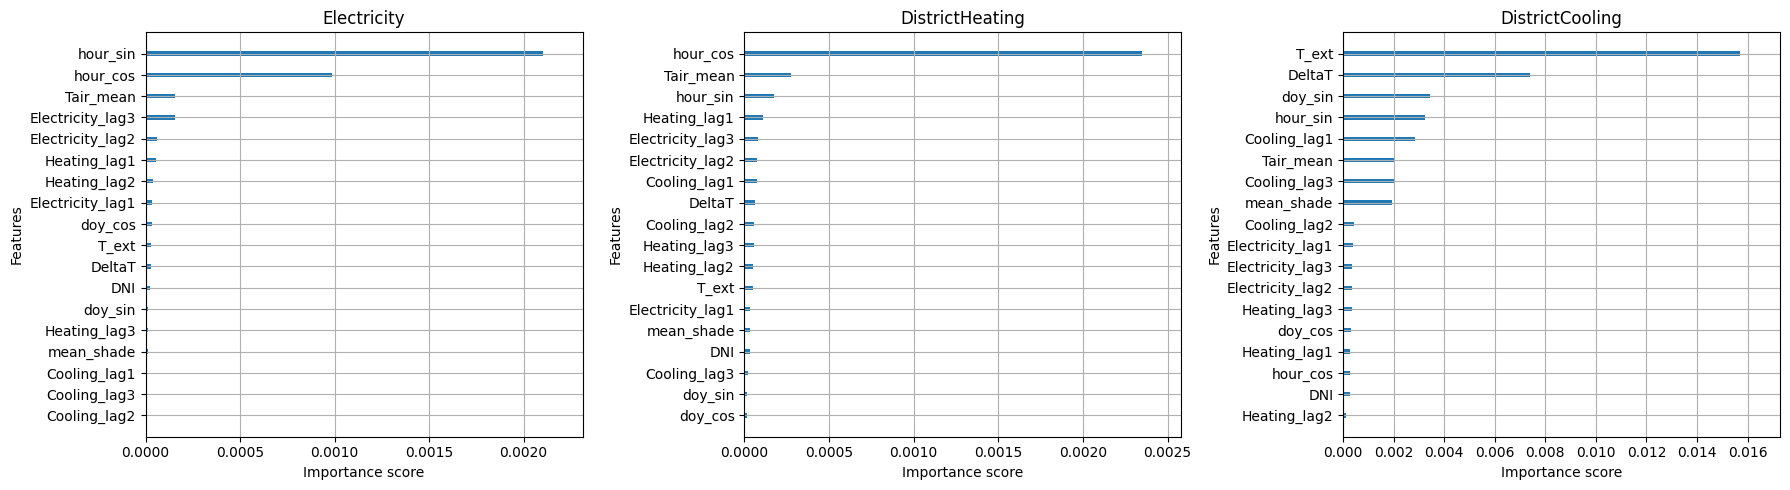

In [11]:
# Visualize feature importance
model.plot_feature_importance()

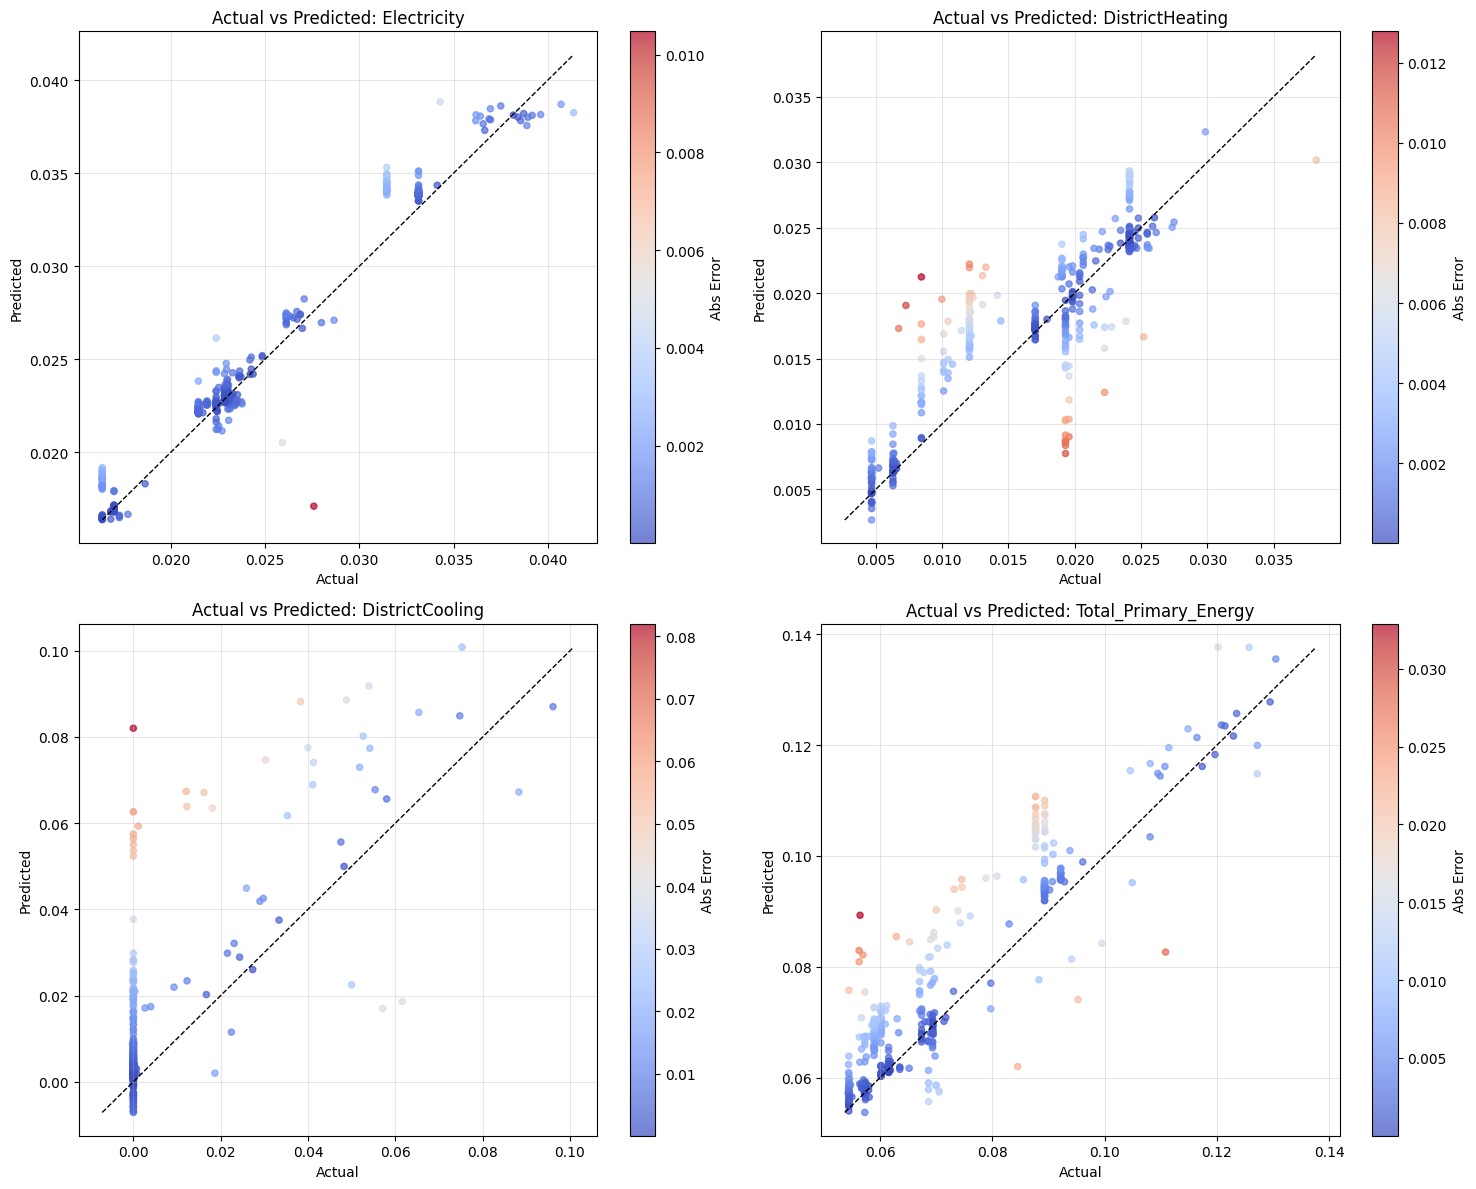

In [12]:
# Plot predicted vs actual scatter plots
model.plot_scatter_error()

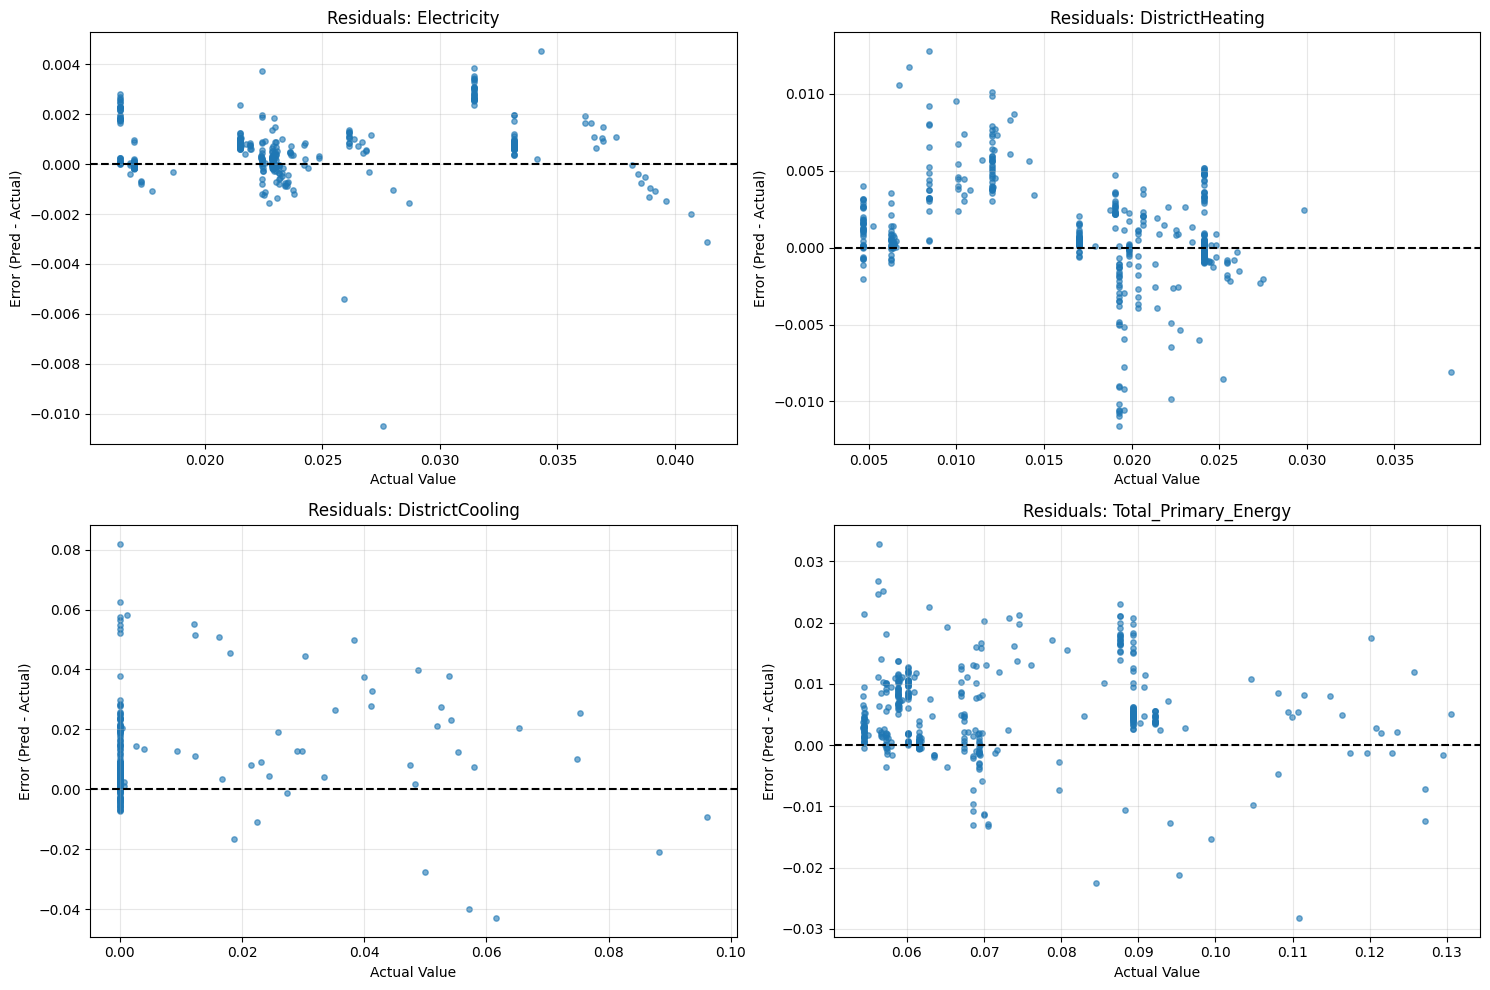

In [13]:
# Plot residual errors
model.plot_error_vs_actual()

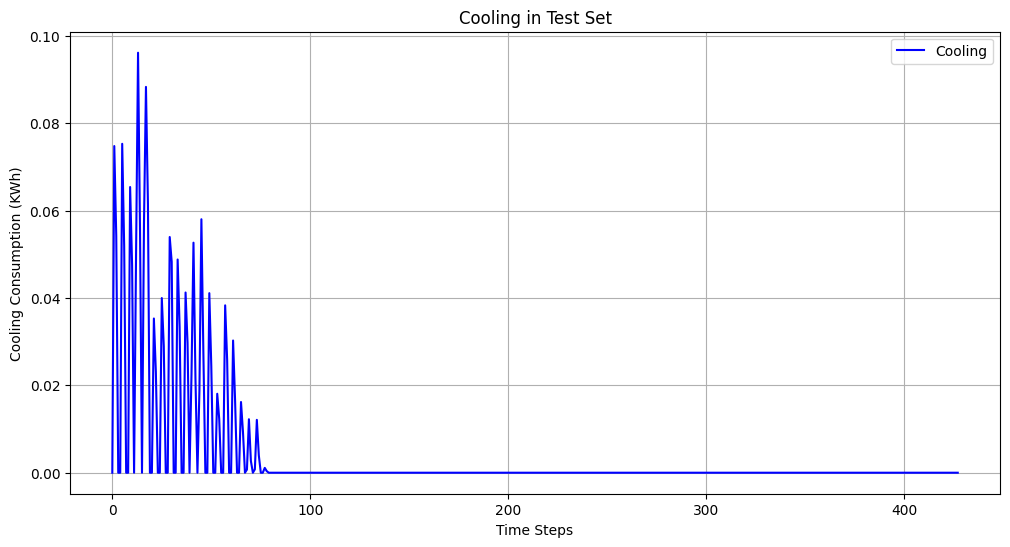

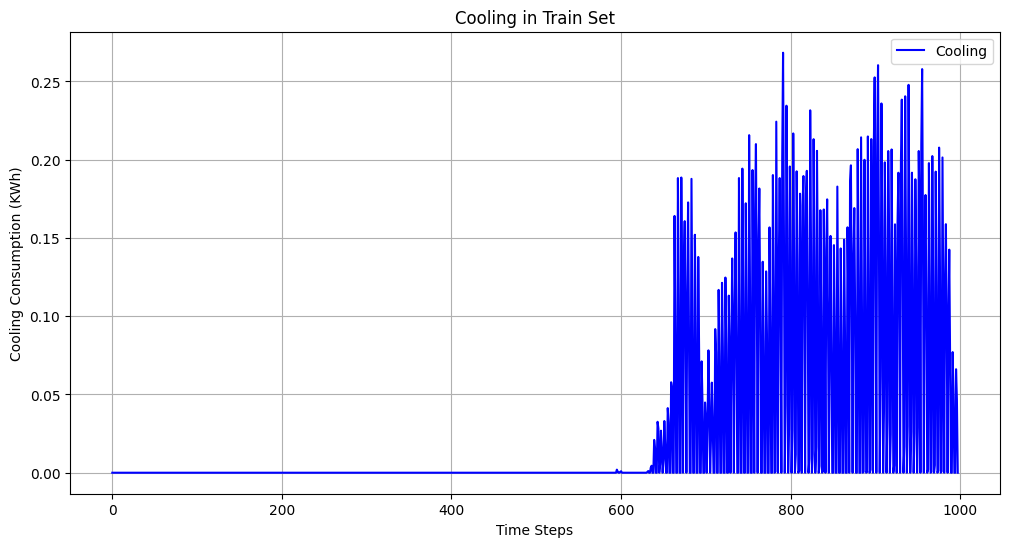

In [14]:
# read csv files
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

# show trend of electricity consumption in the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test['DistrictCooling'].values, label='Cooling', color='blue')
plt.title('Cooling in Test Set')
plt.xlabel('Time Steps')
plt.ylabel('Cooling Consumption (KWh)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(y_train['DistrictCooling'].values, label='Cooling', color='blue')
plt.title('Cooling in Train Set')
plt.xlabel('Time Steps')
plt.ylabel('Cooling Consumption (KWh)')
plt.legend()
plt.grid(True)
plt.show()

**LSTM**

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# feature e target
feature_cols = [
    'T_ext', 'DNI', 'Tair_mean', 'DeltaT', 'mean_shade',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
    'Electricity', 'DistrictHeating', 'DistrictCooling'  # autoregressive
]
target_cols = ['Electricity', 'DistrictHeating', 'DistrictCooling']

split = int(len(dataset) * 0.7)
train_df = dataset.iloc[:split].copy()
test_df  = dataset.iloc[split:].copy()

# scaling
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_raw = x_scaler.fit_transform(train_df[feature_cols])
X_test_raw  = x_scaler.transform(test_df[feature_cols])

y_train_raw = y_scaler.fit_transform(train_df[target_cols])
y_test_raw  = y_scaler.transform(test_df[target_cols])

def make_sequences(X, y, lookback=16, horizon=1):
    Xs, ys = [], []
    for t in range(lookback, len(X) - horizon + 1):
        Xs.append(X[t - lookback:t, :])
        ys.append(y[t + horizon - 1, :])
    return np.array(Xs), np.array(ys)

# with timestep = 6h -> lookback 16 = 4 days (try also: 8, 28)
lookback = 16
horizon = 1

X_train_seq, y_train_seq = make_sequences(X_train_raw, y_train_raw, lookback, horizon)
X_test_seq,  y_test_seq  = make_sequences(X_test_raw,  y_test_raw,  lookback, horizon)

print(X_train_seq.shape, y_train_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(984, 16, 12) (984, 3)
(413, 16, 12) (413, 3)


In [16]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

LSTM_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(lookback, 12)),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='linear')  # 3 targets only
])

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)
LSTM_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')]
)
LSTM_model.summary()

[]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,779 (483.51 KB)

 Trainable params: 123,779 (483.51 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import time
import tensorflow as tf

start_time = time.time()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode='min',
    verbose=1
)

history = LSTM_model.fit(
    X_train_seq, y_train_seq,
    batch_size=32,
    validation_split=0.2,
    epochs=300,
    callbacks=[early_stopping, reduce_lr],
    shuffle=False,
)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")
print(f"Training stopped at epoch: {len(history.history['loss'])}")

Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.3390 - mae: 0.6665 - val_loss: 0.5472 - val_mae: 0.9169 - learning_rate: 3.0000e-04
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3165 - mae: 0.6241 - val_loss: 0.5148 - val_mae: 0.8982 - learning_rate: 3.0000e-04
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3054 - mae: 0.6067 - val_loss: 0.5009 - val_mae: 0.8912 - learning_rate: 3.0000e-04
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2988 - mae: 0.5820 - val_loss: 0.4949 - val_mae: 0.8865 - learning_rate: 3.0000e-04
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2942 - mae: 0.5785 - val_loss: 0.4900 - val_mae: 0.8853 - learning_rate: 3.0000e-04
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2880 - mae: 0.5686 - val_loss: 0.4873 - val_mae: 0.8801 - learning_rate: 3.0000e-04
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.2834 - mae: 0.5608 - val_loss: 0.4813 - val_mae: 0.8711 - lear

In [18]:
# test the model on the test set
y_pred = LSTM_model.predict(X_test_seq)

# inverse-transform the three direct targets
y_pred_rescaled = y_scaler.inverse_transform(y_pred)
y_true_rescaled = y_scaler.inverse_transform(y_test_seq)

# build Total Primary Energy from predicted/true direct targets
# order: [Electricity, DistrictHeating, DistrictCooling]
tpe_true = (
    (y_true_rescaled[:, 1] / COP_H * PE_GAS) +
    (y_true_rescaled[:, 2] / EER_C * PE_ELEC) +
    (y_true_rescaled[:, 0] * PE_ELEC)
)
tpe_pred = (
    (y_pred_rescaled[:, 1] / COP_H * PE_GAS) +
    (y_pred_rescaled[:, 2] / EER_C * PE_ELEC) +
    (y_pred_rescaled[:, 0] * PE_ELEC)
)

# arrays used for metrics/plots (3 direct targets + derived TPE)
y_true_eval = np.column_stack([y_true_rescaled, tpe_true])
y_pred_eval = np.column_stack([y_pred_rescaled, tpe_pred])
eval_names = ['Electricity', 'DistrictHeating', 'DistrictCooling', 'Total_Primary_Energy']

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [19]:
# Metrics per target feature

for i, name in enumerate(eval_names):
    y_true_i = y_true_eval[:, i]
    y_pred_i = y_pred_eval[:, i]

    r2 = r2_score(y_true_i, y_pred_i)
    mse = mean_squared_error(y_true_i, y_pred_i)
    nmse = mse / (np.var(y_true_i) + 1e-8)

    print(f"{name:22s} -> R2: {r2:.4f} | NMSE: {nmse:.4f} | MSE: {mse:.6e}")

Electricity            -> R2: 0.7852 | NMSE: 0.2147 | MSE: 8.143447e-06
DistrictHeating        -> R2: 0.1405 | NMSE: 0.8594 | MSE: 4.308289e-05
DistrictCooling        -> R2: -30.3496 | NMSE: 31.3466 | MSE: 3.237060e-03
Total_Primary_Energy   -> R2: -1.9772 | NMSE: 2.9770 | MSE: 7.600002e-04


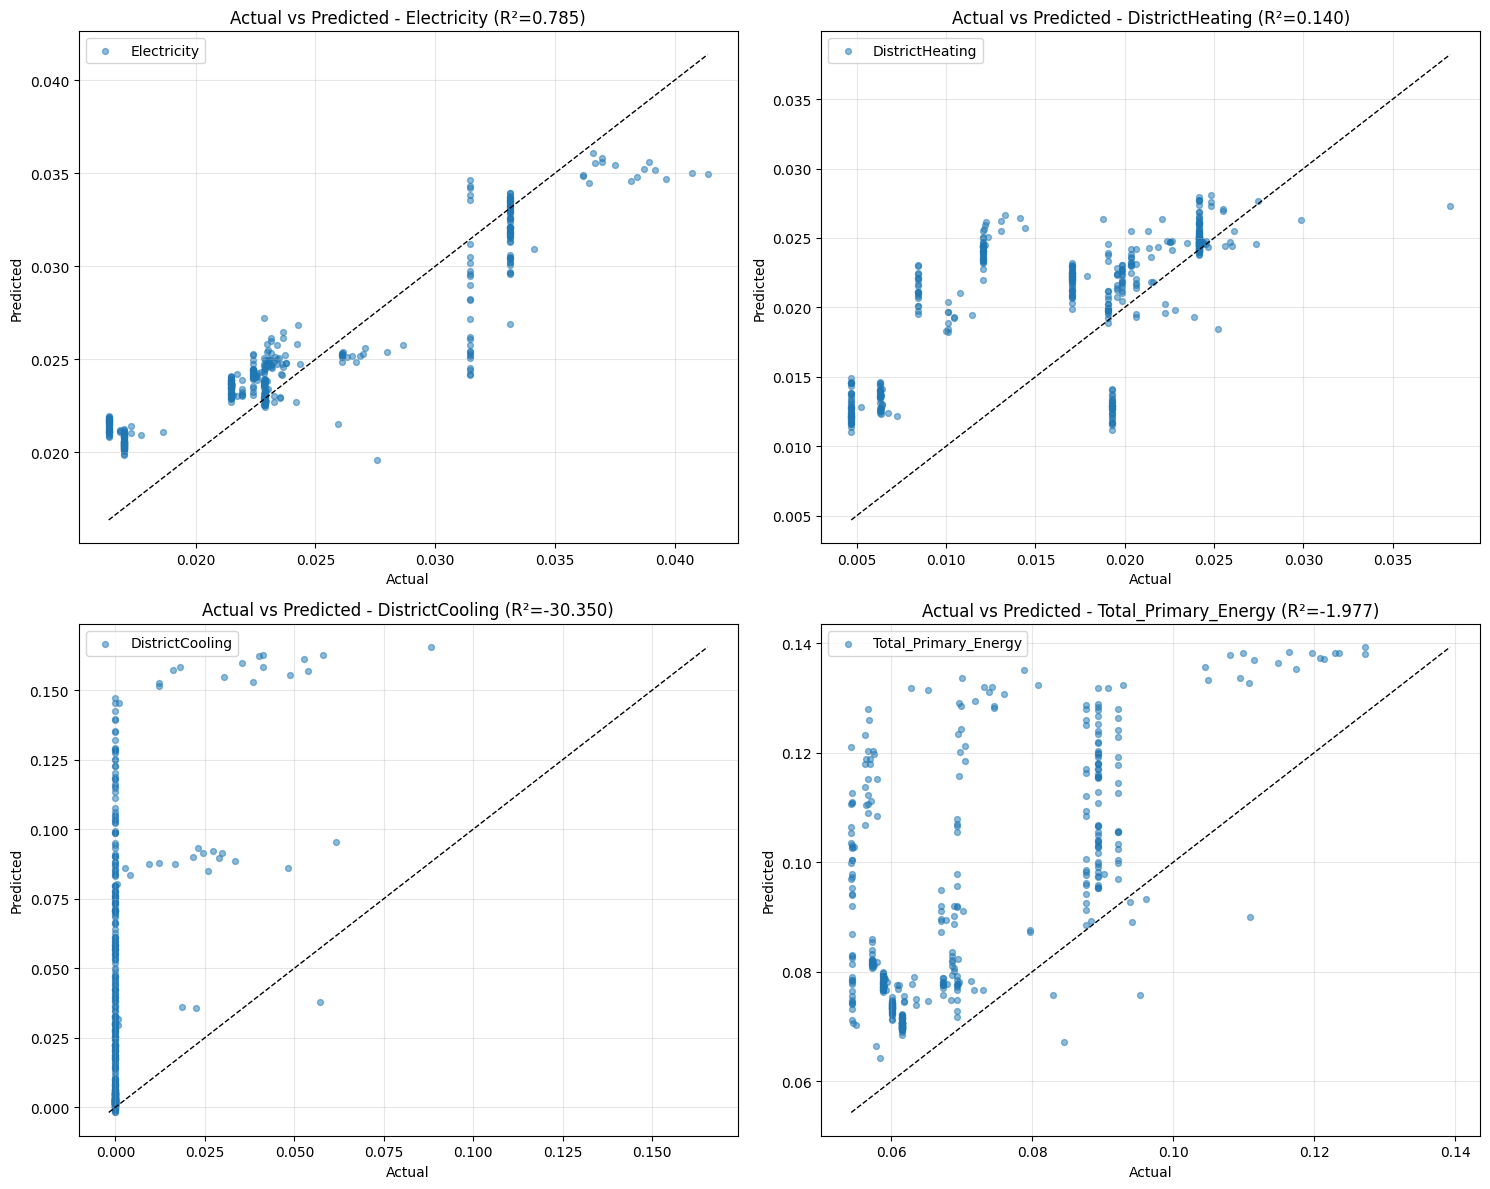

In [20]:
# Actual vs Predicted scatter plots for each target

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, name in enumerate(eval_names):
    ax = axes[i]
    y_true_i = y_true_eval[:, i]
    y_pred_i = y_pred_eval[:, i]

    ax.scatter(y_true_i, y_pred_i, alpha=0.5, s=18, label=name)

    min_v = min(y_true_i.min(), y_pred_i.min())
    max_v = max(y_true_i.max(), y_pred_i.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1)

    r2_i = r2_score(y_true_i, y_pred_i)
    ax.set_title(f'Actual vs Predicted - {name} (R²={r2_i:.3f})')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()